# End-to-End Vulnerability Analysis on MDOF System using Multiple Stripe Analysis

## Introduction

This Jupyter Notebook provides a structured workflow for performing Multiple Stripe Analysis (MSA) on multi-degree-of-freedom (MDOF) structural models. While related to Incremental Dynamic Analysis, MSA subjects a structural model to distinct "stripes" of ground motion records, where each stripe is specifically selected or scaled to represent the unique frequency content and hazard characteristics at a predefined intensity level. This produces a discrete statistical distribution of structural responses (e.g., maximum interstorey drift) at specific intensity increments (e.g., spectral acceleration), providing a robust probabilistic view of building performance.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Perform Multiple Stripe Analysis (MSA)**: Subject the model to sets of ground motions at discrete intensity levels (stripes) corresponding to multiple return periods. Unlike IDA, which scales a single record until collapse, MSA typically uses different hazard-consistent ground motion suites at different intensities, usually selected using the conditional spectrum method to better account for the varying spectral shapes and hazard characteristics expected at low versus high return periods.

3. **Fragility Analysis via Maximum Likelihood**: Postprocess the "stripes" to determine the capacity of the structure at various limit states. Because MSA results in a set of successful versus collapsed simulations at each level, we use statistical methods (such as Maximum Likelihood Estimation) to construct fragility functions that describe the probability of exceeding a damage state as a function of ground-shaking intensity.

4. **Vulnerability Analysis**: Integrate these fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable (such as repair cost ratio) and increasing levels of ground-shaking intensities.

The notebook provides a step-by-step guide, covering each phase from MDOF model creation and ground motion suite organization to analysis execution and detailed results extraction. Users should have some familiarity with Python scripting, structural dynamics, computational modeling, and performance-based earthquake engineering (PBEE) to fully benefit from this material.

---

## References

[1] Jalayer F. and Cornell C.A. (2009). Alternative Nonlinear Demand Estimation Methods for Probability-Based Seismic Assessments, Earthquake Engineering and Structural Dynamics, 38(8): pp. 951-972.

[2] Jalayer F. (2003). Direct Probabilistic Seismic Analysis: Implementing Non-linear Dynamic Assessments, Ph.D. Thesis, Department of Civil and Environmental Engineering, Stanford, CA.

[3] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part I: Hazard consistency for risk-based assessments. Earthquake Engng Struct. Dyn., 42: 1847-1865. https://doi.org/10.1002/eqe.2301

[4] Lin, T., Haselton, C.B. and Baker, J.W. (2013), Conditional spectrum-based ground motion selection. Part II: Intensity-based assessments and evaluation of alternative target spectra. Earthquake Engng Struct. Dyn., 42: 1867-1884. https://doi.org/10.1002/eqe.2303

[5] Bazzurro, P., Cornell A. (1999), Disaggregation of seismic hazard. Bulletin of the Seismological Society of America; 89 (2): 501–520. doi: https://doi.org/10.1785/BSSA0890020501

[6] Baker JW. Efficient Analytical Fragility Function Fitting Using Dynamic Structural Analysis. Earthquake Spectra. 2015;31(1):579-599. doi:10.1193/021113EQS025M

[7] Pagani, M., Monelli, D.,  Weatherill, G., Danciu, L., Crowley, H., Silva, V., Henshaw, P., Butler, L., Nastasi, M., Panzeri, L., Simionato, M., Vigano, D., (2014) OpenQuake Engine: An Open Hazard (and Risk) Software for the Global Earthquake Model. Seismological Research Letters; 85 (3): 692–702. doi: https://doi.org/10.1785/0220130087

[8] Rao A, Yepes-Estrada C, Johnson K, et al. Evolution of the OpenQuake Engine: Enhanced capabilities, collaborative development, and global adoption. Earthquake Spectra. 2025;41(5):3299-3336. doi:10.1177/87552930251378157

## Initialize Libraries ##

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.units         import units              # OQ-VMTK units class
from openquake.vmtk.calibration   import calibrate_model    # OQ-VMTK sdof-to-mdof calibration class
from openquake.vmtk.im_calculator import IMCalculator       # OQ-VMTK intensity measure processor class
from openquake.vmtk.modeller      import modeller           # OQ-VMTK numerical modelling class
from openquake.vmtk.postprocessor import postprocessor      # OQ-VMTK postprocessing class
from openquake.vmtk.plotter       import plotter            # OQ-VMTK plotting class
from openquake.vmtk.utilities     import sorted_alphanumeric, import_from_pkl, export_to_pkl # OQ-VMTK utility class

## Define Directories ##

In [2]:
# Define the directory of the ground-motion records
gm_directory  = './in/records'            

# Define the main output directory
msa_directory = './out'  
os.makedirs(msa_directory, exist_ok=True)

## Load Hazard-Consistent Acceleration Time-Histories and Process Intensity Measures ## 

The suite of ground‐motion records was selected using the **Conditional Mean Spectrum (CMS) method** [3,4], based on a **hazard disaggregation analysis** [5] performed for a site located in **Lisbon, Portugal**, using the **OpenQuake Engine** [7,8]. Classical probabilistic seismic hazard assessment is carried out to identify the intensity measure (IM) levels at each user-defined return period. The disaggregation results were used to identify the controlling earthquake scenarios (magnitude–distance–epsilon) associated with the target hazard levels. Additional information, such as demos and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/demos/hazard/Disaggregation) and documentation (accessible on: https://docs.openquake.org/oq-engine/manual/latest/user-guide/outputs/disaggregation-outputs.html), respectively.

The record selection was conditioned on the **spectral acceleration at the fundamental period, $SA(T_{1})$** of the case-study **multi-degree-of-freedom (MDOF) stick model**, with a fundamental period of **T ≈ 0.19 s**. Separate sets of ground-motion records were selected to represent different seismic hazard levels corresponding to distinct return periods (i.e., from 22 to 9475 years). This approach ensures comprehensive coverage of the structural response domain, from the onset of yielding and nonlinear behavior to collapse mechanisms or dynamic instability.

**Figure 1** presents the ground-motion records selected for a **return period of 42 years**, while **Figure 2** shows the records selected for a **return period of 975 years**, representing rare, high-intensity seismic events.

<p align="center">
  <img src="./in/records/42/Selected.png" width="60%">
  <br>
  <strong>Figure 1.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 42 years.
</p>

<p align="center">
  <img src="./in/records/975/Selected.png" width="60%">
  <br>
  <strong>Figure 2.</strong> Ground-motion records conditioned at $SA(T_{1}=0.19s)$ and selected for a site in L'Aquila, Italy using the CMS method for a return period of 975 years.
</p>

In [3]:
# Input the intensity measure types required for processing
IMT = ['SA(0.19)']

# Input return periods
RP = ['22', '42', '72', '140', '224', '475', '975', '2475', '4975']

# Initialise hierarchical IM storage
imls = {}
imls = {rp: {imt: [] for imt in IMT} for rp in RP}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, current_rp)

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str).flatten()
    dts  = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)
   
    # Loop over ground-motion records per return period
    for i in range(len(gmrs)):

        # Load acceleration time history and time-step
        current_gmr_name = gmrs[i]
        current_acc      = np.loadtxt(os.path.join(current_rp_folder, f'{current_gmr_name}'))
        current_dt  = dts[i]
  
        # Initialise IM calculator
        im_calculator = IMCalculator(current_acc, current_dt)
        
        # Compute the intensity measure levels for AvgSA (example: auto-defined range around T=0.2) for each record and for each return period
        T_star     = 0.19                         # Define the conditioning period
        sa019      = im_calculator.get_sa(T_star) # Calculate the spectral acceleration
        
        # Store IMs by return period: this will be then used in NLTHA for MSA
        imls[current_rp]['SA(0.19)'].append(sa019)

# Export to pickle format 
export_to_pkl(os.path.join(gm_directory,'imls_Lisbon.pkl'), imls)

## Calibrate and Compile an MDOF Model based on SDOF Capacity ##

In [4]:
# Number of storeys
number_storeys = 2

# Relative floor heights list
storey_heights = [2.80, 2.80]

# First-mode based participation factor
gamma = 1.33

# SDOF capacity (First row are Spectral Displacement [m] values - Second row are Spectral Acceleration [g] values)
sdof_capacity = np.array([[0.00060789, 0.00486316, 0.02420000, 0.04353684], 
                          [0.10315200, 0.20630401, 0.12378241, 0.12502023]]).T
# Frame flag
isFrame = False

# Soft-storey mechanism flag
isSOS = False

# Degradation flag 
mdof_degradation = True

# Inherent damping 
mdof_damping = 0.05

# Calibrate the model
floor_masses, storey_drifts, storey_forces, mdof_phi, meta = calibrate_model(number_storeys,
                                                                             sdof_capacity,
                                                                             isSOS=isSOS,
                                                                             storey_heights=storey_heights,
                                                                             verbose=False)

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Stopped because of load factor below zero


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


## Setting Up, Running MSAs and Exporting Analysis ##

In the next code snippet, MSA is carried out on the stick model using the selected hazard-consistent record sets.

For each ground-motion record, the MDOF model is compiled, gravity-loaded, and subjected to modal analysis to extract its dynamic properties. The ground motion is then applied through NLTHA using consistent time-stepping, appropriate unit scaling, and specified damping.

The analysis extracts key engineering demand parameters (EDPs), including peak storey drifts, peak floor accelerations, and peak floor displacements along the building height. Maximum response values, together with their associated directions and locations, are also recorded. Numerical convergence is monitored through a convergence index.

All response quantities are stored for each record and aggregated into a structured dataset, which is exported for subsequent fragility development, and vulnerability analysis.

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


======== MSA Analysing RP:22 years, Record 1 out of 20 =========


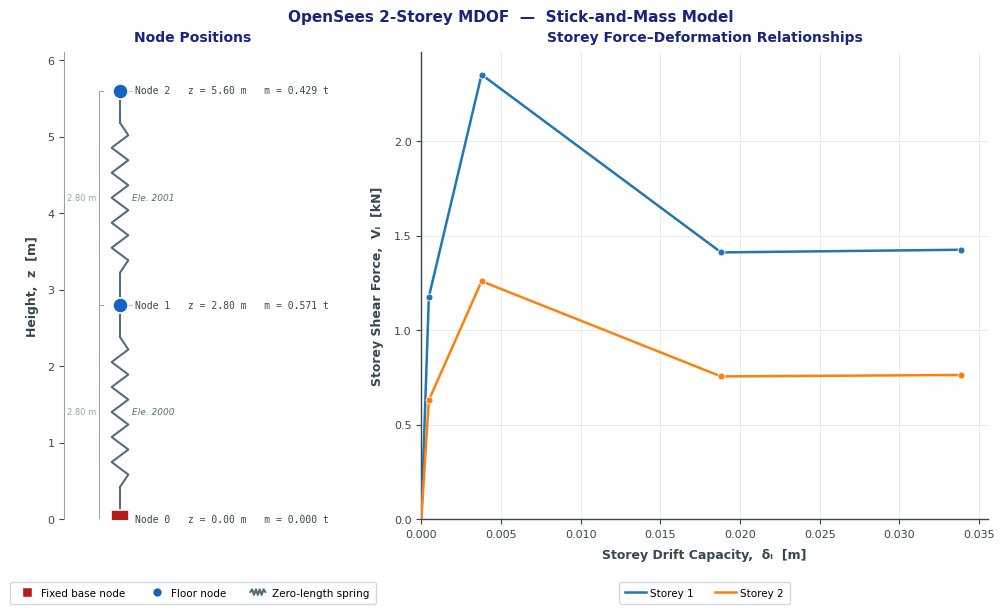

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [7.24087971e-05 1.14012244e-04] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.005619456177325926), np.float64(0.006292115188079213), np.float64(0.00800931385973273)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0001140122440516886 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.00800931385973273 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [6.70899398e-05 8.85227458e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0027388943215573666), np.float64(0.004662170955920811), np.float64(0.006550136295795582)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 8.852274583935344e-05 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.006550136295795582 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [5.13720551e-05 3.13744508e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0016951150439142241), np.float64(0.0025257132474637025), np.float64(0.0029127697655480754)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 5.1372055118422496e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0029127697655480754 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [5.01534663e-05 4.44350518e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0017076165970667959), np.float64(0.002192228433554959), np.float64(0.0033722585963495435)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 5.015346634089162e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0033722585963495435 encountered in X direction on storey # 2
======== MSA Analysing RP:22 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [6.36617387e-05 5.83092716e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.00226902280926663), np.float64(0.0027407596146433746), np.float64(0.003887778828611012)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 6.366173870927496e-05 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.003887778828611012 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


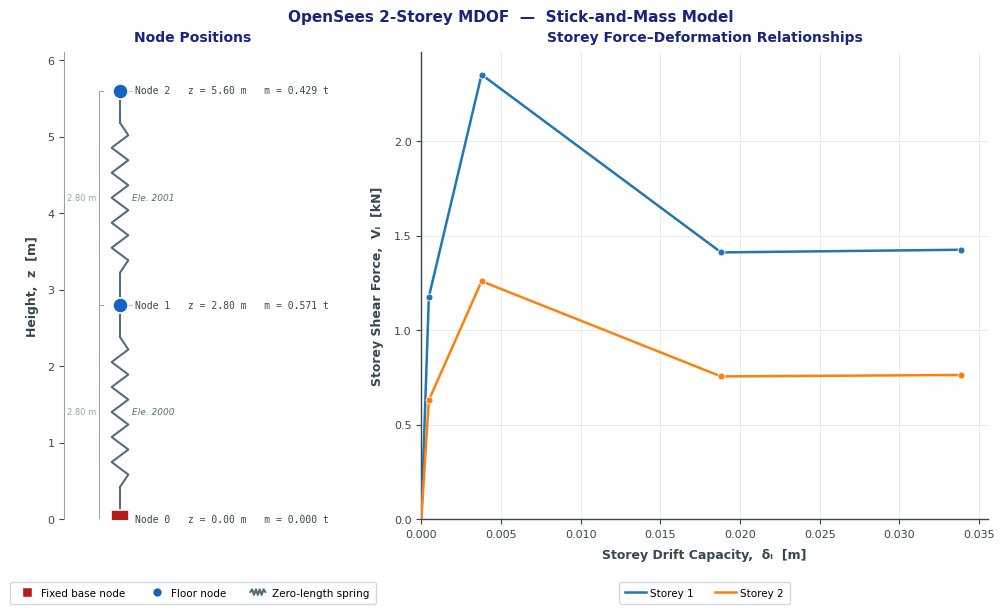

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00012196 0.00010272] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.007581990435505261), np.float64(0.007871131352395106), np.float64(0.007923907789347326)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00012196029483120184 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.007923907789347326 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [8.00377541e-05 1.20779753e-04] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0024153780316839998), np.float64(0.005290389673469989), np.float64(0.00870457699945476)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0001207797525428459 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.00870457699945476 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0001192 0.0001048] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.002975146506732366), np.float64(0.005704449083712827), np.float64(0.007956103861791098)] g
Peak accelerati

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [9.14286977e-05 9.91955264e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0034357595646649216), np.float64(0.005137444838423085), np.float64(0.007523794141817737)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 9.919552642503972e-05 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.007523794141817737 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 5 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [1.06551461e-04 9.05119076e-05] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0029851562273939323), np.float64(0.005440428335844006), np.float64(0.006755063050808214)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0001065514612339981 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.006755063050808214 encountered in X direction on storey # 2
======== MSA Analysing RP:42 years, Record 20 out of 20 =========
[0.1539994  0.06969881 0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00010627 0.00014061] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.004455525624748545), np.float64(0.006144774484401905), np.float64(0.0109955144318723)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0001406135459809908 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.0109955144318723 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


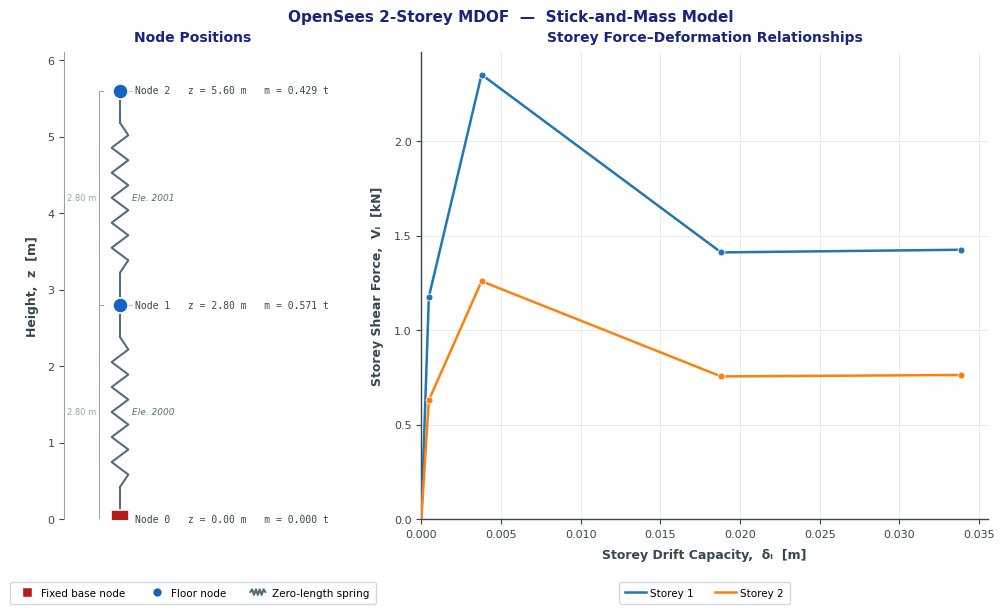

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0001867  0.00021959] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.003948309423499632), np.float64(0.009219340485933591), np.float64(0.015623644610084185)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00021958961105141868 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.015623644610084185 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00018115 0.00029486] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016857719227800272), np.float64(0.024244925532634735), np.float64(0.01711347093429663)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0002948629085436982 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.024244925532634735 encountered in X direction on storey # 1
======== MSA Analysing RP:72 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00017323 0.00011976] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.003756194793546049), np.float64(0.011167095548519548), np.float64(0.011158964644076359)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00017323100179584633 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.011167095548519548 encountered in X direction on storey # 1
======== MSA Analysing RP:72 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00026952 0.00022979] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.0061062681652725385), np.float64(0.011230784332716641), np.float64(0.0163187778220743)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0002695178314171743 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0163187778220743 encountered in X direction on storey # 2
======== MSA Analysing RP:72 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0001607  0.00016718] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.004875380918666178), np.float64(0.00910879941200854), np.float64(0.013540367295174676)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0001671778218702851 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.013540367295174676 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


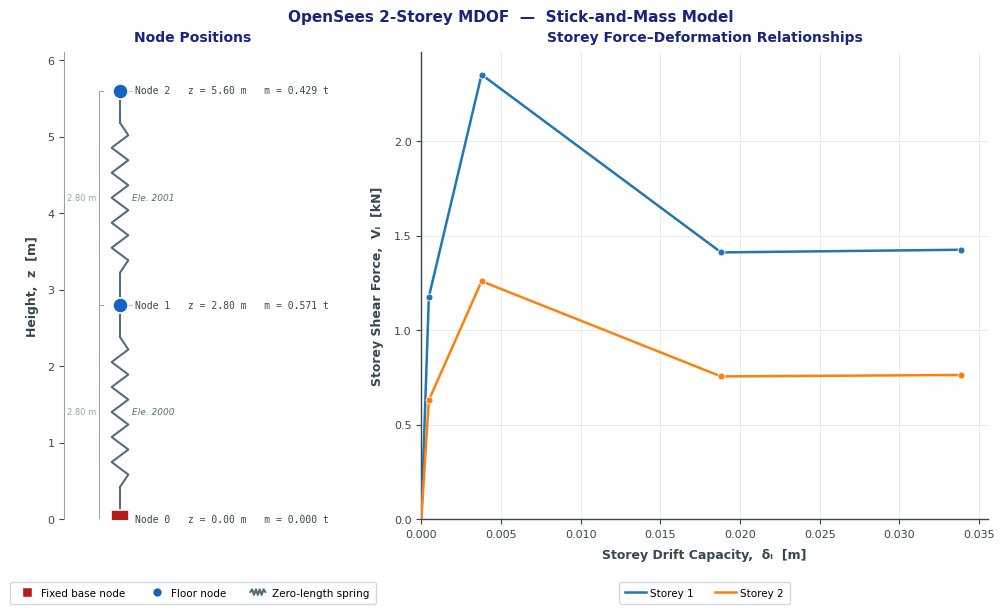

[0.1539994  0.06969881 0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00024556 0.00059052] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.009536686210338605), np.float64(0.01630509211795619), np.float64(0.02021435400085847)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005905236169549878 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02021435400085847 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00037677 0.00020387] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.006404449810440932), np.float64(0.019062029465481883), np.float64(0.015898544740617925)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0003767741961713307 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.019062029465481883 encountered in X direction on storey # 1
======== MSA Analysing RP:140 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00017708 0.00040879] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.006188241685533911), np.float64(0.01452168261267885), np.float64(0.01789028875418511)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004087934170832849 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.01789028875418511 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00037532 0.00035976] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.008065624419786631), np.float64(0.014543851786952392), np.float64(0.01786541627259572)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0003753178034728205 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.01786541627259572 encountered in X direction on storey # 2
======== MSA Analysing RP:140 years, Record 20 out of 20 =========
[0.1539994  0.06969881 0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00017392 0.00050249] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.009750816272112026), np.float64(0.017788515910653016), np.float64(0.01880783904846946)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005024912512605007 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.01880783904846946 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


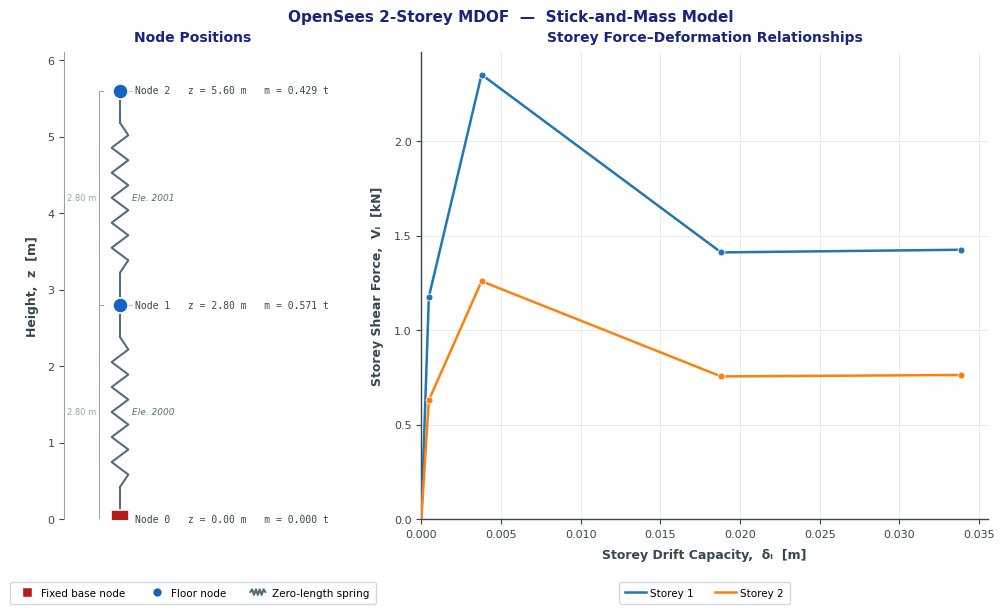

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00033303 0.00064728] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.015052138743474273), np.float64(0.03319475378890871), np.float64(0.02051950454938806)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000647283708125099 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03319475378890871 encountered in X direction on storey # 1
======== MSA Analysing RP:224 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00036806 0.00054778] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.00811085786820327), np.float64(0.013403437103822005), np.float64(0.01968323115344685)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0005477823501259468 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.01968323115344685 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00044967 0.00049612] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.008386459819483542), np.float64(0.015397525355191396), np.float64(0.019133997995857584)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0004961247875621169 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.019133997995857584 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0005959  0.00083375] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.011351684349361712), np.float64(0.01704396380373494), np.float64(0.02227244410097331)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0008337515883047651 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02227244410097331 encountered in X direction on storey # 2
======== MSA Analysing RP:224 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00061423 0.00072607] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.018884223861846676), np.float64(0.021554852532766847), np.float64(0.02184817585586095)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0007260670505425198 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02184817585586095 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


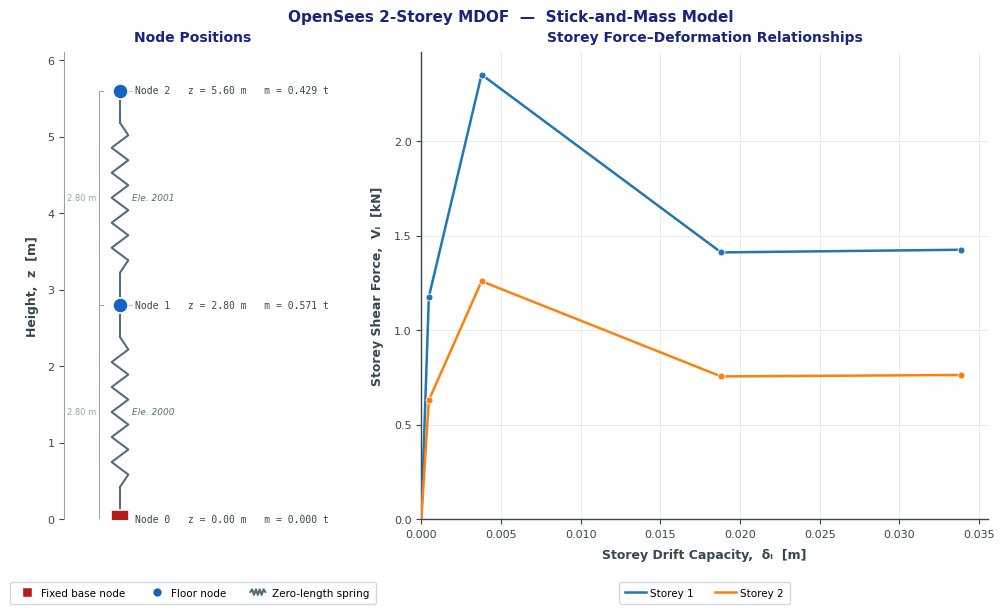

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00040408 0.00075606] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02060244794556053), np.float64(0.02072936536361444), np.float64(0.02207022805615436)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0007560619302791861 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02207022805615436 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 2 out of 20 =========
[0.1539994  0.06969881 0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0005534  0.00081545] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.012817156161800092), np.float64(0.022176026080042755), np.float64(0.023003935640851157)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0008154533881111757 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.023003935640851157 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00089637 0.00100105] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016809047596618602), np.float64(0.017741495847020092), np.float64(0.024810997507094642)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0010010466682383843 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.024810997507094642 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 4 out of 20 =========
[0.1539994  0.06969881 0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00063359 0.00073401] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.015694794981456827), np.float64(0.01779999524780852), np.float64(0.022051471032598406)] g
Peak acceleration va

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00084831 0.0017255 ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.023442657615384235), np.float64(0.026661458370649586), np.float64(0.031487812339303194)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0017255006329672934 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.031487812339303194 encountered in X direction on storey # 2
======== MSA Analysing RP:475 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00056131 0.00111066] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.016531039949337578), np.float64(0.023898630227684566), np.float64(0.02658697894599607)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.001110664372619272 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02658697894599607 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


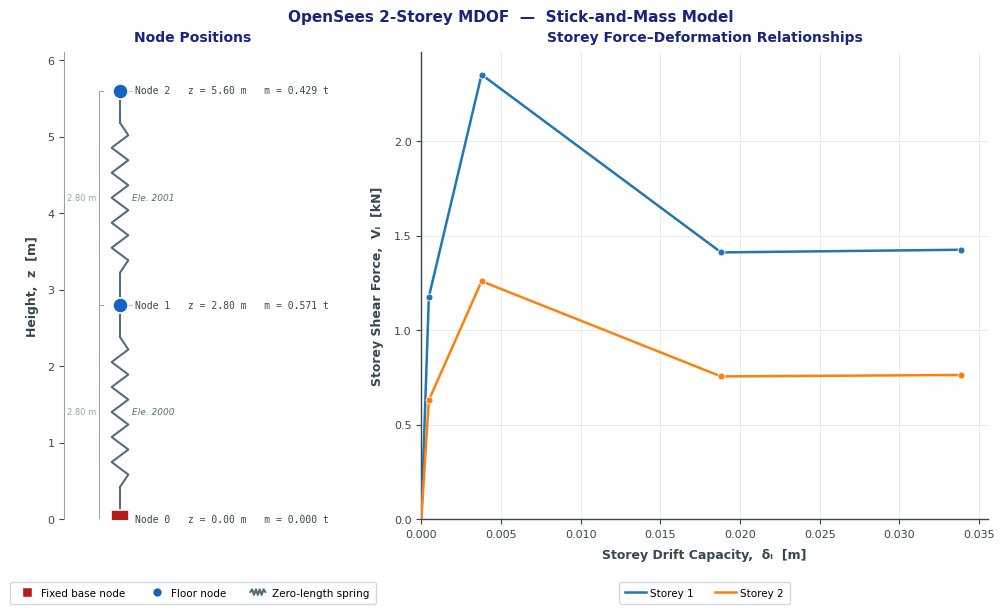

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.05882479 0.01125634] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03927945122840653), np.float64(0.03904168343985895), np.float64(0.031987873408643654)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.05882479281787456 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03927945122840653 encountered in X direction on storey # 0
======== MSA Analysing RP:975 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0005234 0.0010049] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03013916778754476), np.float64(0.027164388719838697), np.float64(0.0252711595649037)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0010049004460792716 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03013916778754476 encountered in X direction on storey # 0
======== MSA Analysing RP:975 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00048103 0.00114975] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.01198386030141546), np.float64(0.021901691154339018), np.float64(0.02529373904999914)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0011497514757676695 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02529373904999914 encountered in X direction on storey # 2
======== MSA Analysing RP:975 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0011632  0.00187065] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.020896391661301854), np.float64(0.03174304432072755), np.float64(0.03192139173024615)] g
Peak acceleration values

...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00124698 0.00152494] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02168776013867956), np.float64(0.035835944208504764), np.float64(0.02936588054999805)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0015249401818836915 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.035835944208504764 encountered in X direction on storey # 1
======== MSA Analysing RP:975 years, Record 19 out of 20 =========
[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00118203 0.00164751] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.05463349509256796), np.float64(0.03150859051181797), np.float64(0.029109533094136397)] g
Peak acceleration valu

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.0013386  0.00127536] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.026652272365192152), np.float64(0.023193002107376435), np.float64(0.028847157337987133)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0013385998067509859 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.028847157337987133 encountered in X direction on storey # 2
======== MSA Analysing RP:2475 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


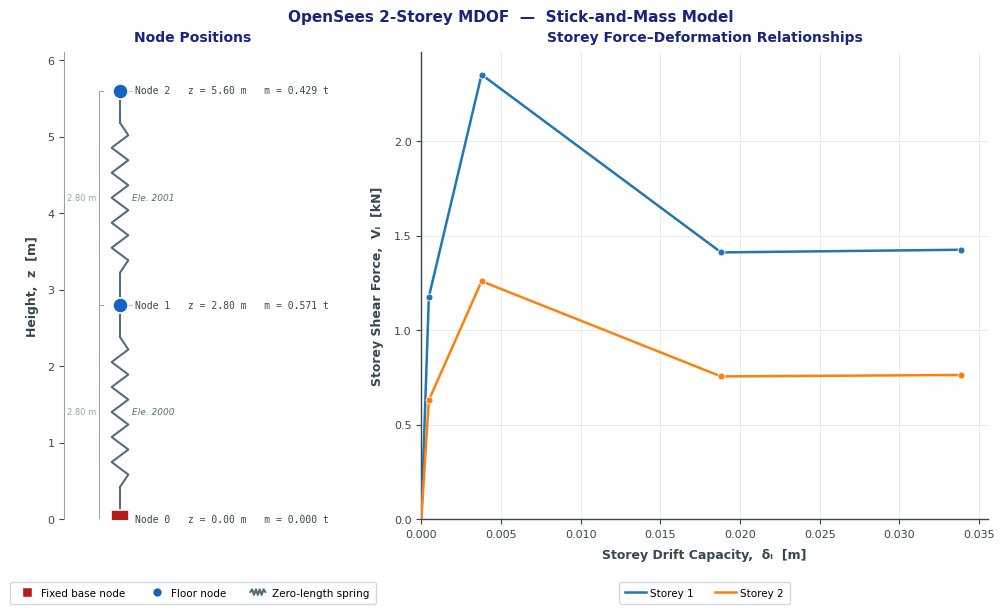

[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.06075339 0.073833  ] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.04491681206859118), np.float64(0.03742191530970091), np.float64(0.03125302068309448)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.07383299622787069 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.04491681206859118 encountered in X direction on storey # 0
======== MSA Analysing RP:2475 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00087907 0.00115509] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02543690311548308), np.float64(0.03122953616034448), np.float64(0.023316711076810142)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0011550949185142835 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03122953616034448 encountered in X direction on storey # 1
======== MSA Analysing RP:2475 years, Record 3 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00190064 0.00312113] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.02185334649153309), np.float64(0.035566336323571805), np.float64(0.03147609531376936)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0031211349772515143 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.035566336323571805 encountered in X direction on storey # 1
======== MSA Analysing RP:2475 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]


...

WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00100246 0.00157378] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.032477543168900905), np.float64(0.03060644408229314), np.float64(0.03138207134124284)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0015737845724661298 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.032477543168900905 encountered in X direction on storey # 0
======== MSA Analysing RP:2475 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00077184 0.00097917] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.018501609476819985), np.float64(0.02457498136309207), np.float64(0.024257545927456027)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.000979174098684272 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.02457498136309207 encountered in X direction on storey # 1
======== MSA Analysing RP:4975 years, Record 1 out of 20 =========


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


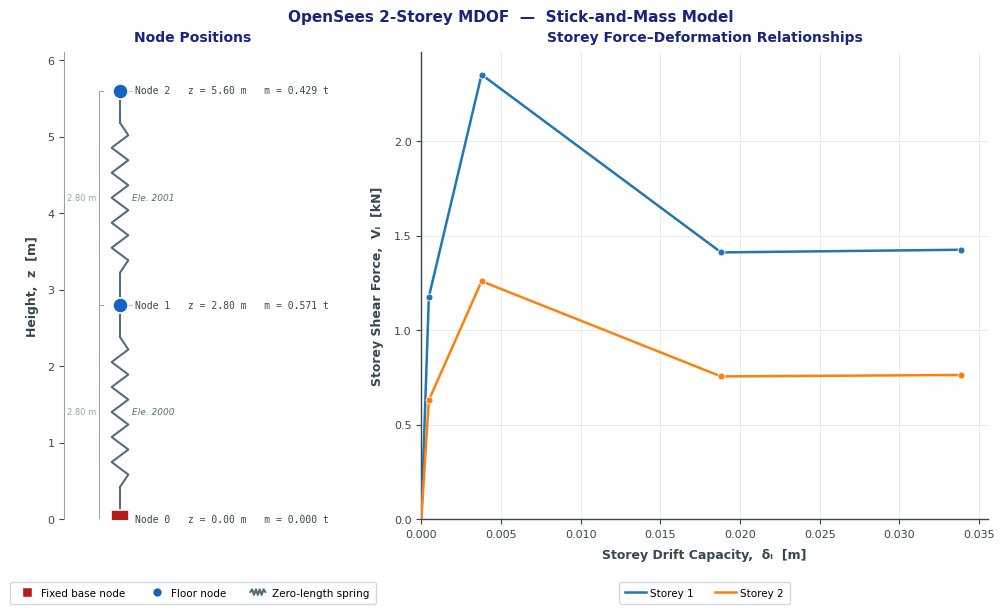

[0.1539994  0.06969881 0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00127628 0.00152287] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.041717943223647885), np.float64(0.032900919422754124), np.float64(0.030513445971024705)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0015228664960469456 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.041717943223647885 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 2 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00104343 0.00118904] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03209094672135143), np.float64(0.03255015880538795), np.float64(0.023441602369627296)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0011890384749990615 encountered in X direction on storey # 2
Maximum peak floor acceleration value of 0.03255015880538795 encountered in X direction on storey # 1
======== MSA Analysing RP:4975 years, Record 3 out of 20 =========
[0.1539994  0.06969881 0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00172534 0.00153717] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03752497268517217), np.float64(0.028866809637585866), np.float64(0.03087264277972397)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0017253423626787817 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.03752497268517217 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 4 out of 20 =========
[0.1539994  0.1539994  0.06969881]
~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00175284 0.00146458] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03503734466966091), np.float64(0.028076560720165848), np.float64(0.03120498119824582)] g
Peak acceleration value

...

~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.11955411 0.00513866] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.07718300541919665), np.float64(0.040174185458346515), np.float64(0.03990179309694943)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.119554107108447 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.07718300541919665 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 19 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00400873 0.00373441] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.05233386228719571), np.float64(0.041950739514898694), np.float64(0.037033334624640625)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.0040087308328123775 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.05233386228719571 encountered in X direction on storey # 0
======== MSA Analysing RP:4975 years, Record 20 out of 20 =========
[0.1539994  0.1539994  0.06969881]


WARNING ZeroLength::setDomain(): Element 2000 has L= 2.8, which is greater than the tolerance
WARNING ZeroLength::setDomain(): Element 2001 has L= 2.8, which is greater than the tolerance


~~~~~~~ ANALYSIS SUCCESSFUL ~~~~~~~~~
Peak drift values in X-direction: [0.00989574 0.00437164] rad
Peak drift values in Y-direction: [0. 0.] rad
Peak acceleration values in X-direction: [np.float64(0.03828944507783191), np.float64(0.0440223912470103), np.float64(0.03302485325991403)] g
Peak acceleration values in Y-direction: [np.float64(0.0), np.float64(0.0), np.float64(0.0)] g
Maximum peak storey drift value of 0.00989573735530177 encountered in X direction on storey # 1
Maximum peak floor acceleration value of 0.0440223912470103 encountered in X direction on storey # 1
ANALYSIS COMPLETED!


In [5]:
# Initialise the hierarchical dictionary
ansys_dict = {}

# Loop over return periods
for current_rp in RP:

    # Current return period folder
    current_rp_folder = os.path.join(gm_directory, str(current_rp))

    # Load ground-motion data: acceleration time-histories, time-steps and durations
    gmrs = np.loadtxt(os.path.join(current_rp_folder, 'GMR_H1_names.txt'), dtype=str)
    dts  = np.loadtxt(os.path.join(current_rp_folder, 'GMR_dts.txt'), dtype=float)

    # Initialise storage for this return period
    ansys_dict[current_rp] = {'T': None,
                              'conv_index_list': [],
                              'peak_disp_list': [],
                              'peak_drift_list': [],
                              'peak_accel_list': [],
                              'max_peak_drift_list': [],
                              'max_peak_drift_dir_list': [],
                              'max_peak_drift_loc_list': [],
                              'max_peak_accel_list': [],
                              'max_peak_accel_dir_list': [],
                              'max_peak_accel_loc_list': []}
    
    # Loop over ground-motion records
    for i in range(len(gmrs)):
        print('================================================================')
        print('======== MSA Analysing RP:{:s} years, Record {:d} out of {:d} ========='.format(current_rp, i+1, len(gmrs)))
        print('================================================================')

        # Initialise the modeller class and compile the MDOF model 
        model = modeller(number_storeys, 
                         storey_heights, 
                         floor_masses,
                         storey_drifts, 
                         storey_forces*units.g, 
                         mdof_degradation)
        model.compile_model()

        # Plot the model only for the first ground-motion record
        if i == 0:
            model.plot_model()        

        # Do gravity analysis for system equilibrium
        model.do_gravity_analysis()

        # Do modal analysis
        num_modes = 1 if number_storeys == 1 else 3
        T, phi = model.do_modal_analysis(num_modes=num_modes, plot_modes=False)
        print(T)
    
        # Define ground motion objects
        fnames   = [os.path.join(current_rp_folder, f'{gmrs[i]}')]
        current_acc = np.loadtxt(os.path.join(current_rp_folder, gmrs[i]))   # Load the acceleration (only to calculate the duration)
        dt_gm = dts[i]                                                       # Get the time-step           
        t_max = len(current_acc) * dt_gm                                     # Get the maximum duration
        dt_ansys = dt_gm                                                     # Set the analysis time-step equal to the ground-motion time-step
    
        # Run Multiple Stripe Analysis:
        # There is no dedicated function in OQ-VMTK for MSA, instead we are calling the do_nrha_analysis
        # method from the modeller class for each record at each return period
        control_nodes, conv_index, peak_drift, peak_accel, max_peak_drift, max_peak_drift_dir, max_peak_drift_loc, max_peak_accel, max_peak_accel_dir, max_peak_accel_loc, peak_disp, _, _ = model.do_nrha_analysis(fnames, 
                                                                                                                                                                                                                    dt_gm, 
                                                                                                                                                                                                                    units.g, 
                                                                                                                                                                                                                    t_max, 
                                                                                                                                                                                                                    dt_ansys,
                                                                                                                                                                                                                    pFlag=False,
                                                                                                                                                                                                                    xi = 0.05) 

        # Print statements
        print('Peak drift values in X-direction:', peak_drift[:,0], 'rad') # Peak drift values in the X-direction
        print('Peak drift values in Y-direction:', peak_drift[:,1], 'rad') # Peak drift values in the Y-direction (Zeros due to uni-directional loading)
        print('Peak acceleration values in X-direction:', [x/9.81 for x in peak_accel[:,0]], 'g') # Peak acceleration values in the X-direction (converted to g)
        print('Peak acceleration values in Y-direction:', [x/9.81 for x in peak_accel[:,1]], 'g') # Peak acceleration values in the Y-direction (converted to g)
        print('Maximum peak storey drift value of', max_peak_drift, 'encountered in', max_peak_drift_dir ,'direction', 'on storey #', max_peak_drift_loc)       # Reporting
        print('Maximum peak floor acceleration value of', max_peak_accel/9.81, 'encountered in', max_peak_accel_dir ,'direction', 'on storey #', max_peak_accel_loc) # Reporting
        
        # Store results in hierarchical dict
        ansys_dict[current_rp]['conv_index_list'].append(conv_index)
        ansys_dict[current_rp]['peak_drift_list'].append(peak_drift)
        ansys_dict[current_rp]['peak_accel_list'].append(peak_accel)
        ansys_dict[current_rp]['peak_disp_list'].append(peak_disp)
        ansys_dict[current_rp]['max_peak_drift_list'].append(max_peak_drift)
        ansys_dict[current_rp]['max_peak_drift_dir_list'].append(max_peak_drift_dir)
        ansys_dict[current_rp]['max_peak_drift_loc_list'].append(max_peak_drift_loc)
        ansys_dict[current_rp]['max_peak_accel_list'].append(max_peak_accel)
        ansys_dict[current_rp]['max_peak_accel_dir_list'].append(max_peak_accel_dir)
        ansys_dict[current_rp]['max_peak_accel_loc_list'].append(max_peak_accel_loc)

# Export the results
export_to_pkl(os.path.join(msa_directory, 'msa_ansys_out.pkl'), ansys_dict)

print('ANALYSIS COMPLETED!')

## Pre-Process Intensity Measure Levels and Engineering Demand Parameters for MSA Post-Processor ##

In [6]:
# Determine dimensions
num_stripes = len(RP)                      # The number of stripes equals the number of return periods considered
num_gmrs = len(imls[RP[0]]['SA(0.19)'])  # The number of ground-motion is equal across all return periods (so we can simply take the length of the first RP IML values)

# Initialize empty arrays
imls_matrix = np.zeros((num_gmrs, num_stripes))
edps_matrix = np.zeros((num_gmrs, num_stripes))

# Loop over RPs to fill the columns
for j, rp in enumerate(RP):
    # Use the dictionary (imls) to fill the array (imls_matrix)
    imls_matrix[:, j] = imls[rp][IMT[0]]                           # The input is the name of the key associated with the IMT (IMT[0] = 'SA(0.2)') 
    edps_matrix[:, j] = ansys_dict[rp]['max_peak_drift_list']      # Options are: 'max_peak_drift_list' or 'max_peak_accel_list'

## Post-Process Multiple Stripe Results: Maximum Likelihood Estimation and Fragility Functions ##

**Multiple Stripe Analysis** [1,2] is an efficient computational procedure used to assess the seismic performance of structures at discrete levels of intensity. MSA serves as an alternative to Incremental Dynamic Analysis (IDA) or Cloud Analysis (CA). While IDA relies on the scaling of a single record until global dynamic instability and unlike CA which utilizes a suite of unscaled "natural" records, MSA involves using a set of hazard-consistent ground motion ensembles [3] at specific intensity measure (IM) levels, or "stripes". These stripes typically correspond to distinct hazard levels, such as specific return periods or targets defined by an "approximate" or "exact" Conditional Mean Spectrum (CMS) [4] in tandem with the results of seismic hazard disaggregation [5]. The CMS can be calculated using the OpenQuake Engine [7,8]. Additional information, such as examples and documentation, on performing hazard disaggregation in OpenQuake is available in the official repository (accessible on: https://github.com/gem/oq-engine/tree/master/openquake/qa_tests_data/conditional_spectrumn) and documentation (accessible on: https://docs.openquake.org/oq-engine/LTS/manual/user-guide/advanced/advanced-calculations.html), respectively. The primary output of MSA for fragility assessment is a set of discrete data points: at each intensity level , a total of  ground motions are analyzed, and the number of cases  exceeding a specific damage state (e.g., collapse) is recorded.

A primary advantage of MSA is its ability to explicitly decouple the intensity measure from the record-selection process at each hazard level. This allows researchers to account for the evolution of spectral shape and ground motion characteristics (e.g., epsilon, duration) as seismic intensity increases. By analyzing structural response distributions at these discrete intervals, MSA captures the aleatory uncertainty (record-to-record variability) and provides the statistical basis for deriving fragility functions through Maximum Likelihood Estimation (MLE) [6].

### Fragility Function Derivation using Maximum Likelihood Estimation (MLE) ###

To translate these discrete observations into a continuous, statistically robust fragility function, Maximum Likelihood Estimation (MLE) is employed. This approach, as detailed by Baker [4], treats the structural response at each stripe as a series of Bernoulli trials, where the outcome is either exceeding or not exceeding a specific limit state.

#### Step 1: The Lognormal Distribution Assumption #### 

The fragility function represents the probability of exceeding a damage state ($DS$) conditioned on the intensity measure ($IM$). It is conventionally modeled using a lognormal cumulative distribution function (CDF):$$P(DS \ge ds \mid IM = im) = \Phi \left( \frac{\ln(im / \theta)}{\beta} \right)$$ where: 
* $\theta$ is the median capacity (the intensity level with a 50% probability of exceedance)
* $\beta$ is the logarithmic standard deviation (dispersion) representing record-to-record variability
* $\Phi(\cdot)$ denotes the standard normal cumulative distribution function.

#### Step 2: Formulating the Likelihood Function #### 

The objective of MLE is to find the parameters $\theta$ and $\beta$ that maximize the likelihood of observing the data obtained from the MSA. For a set of $m$ stripes, the likelihood function $\mathcal{L}$ is the product of the binomial probabilities for each stripe:$$\mathcal{L} = \prod_{j=1}^{m} \binom{n_j}{z_j} \left[ \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right]^{z_j} \left[ 1 - \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right]^{n_j - z_j}$$In practice, it is numerically more stable to maximize the log-likelihood ($\ln \mathcal{L}$), which converts the product into a sum:$$\ln \mathcal{L} = \sum_{j=1}^{m} \left\{ \ln \binom{n_j}{z_j} + z_j \ln \left[ \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right] + (n_j - z_j) \ln \left[ 1 - \Phi \left( \frac{\ln(im_j / \theta)}{\beta} \right) \right] \right\}$$

#### Step 3: Optimization and Total Uncertainty #### 

The optimal estimates for the median ($\hat{\theta}$) and dispersion ($\hat{\beta}$) are obtained by solving the optimization problem that maximizes the log-likelihood function. This method is particularly robust because it utilizes the full data set, including stripes where zero or all records exceed the damage state, without the bias inherent in extrapolating regressions from non-collapse data.The total dispersion $\beta_{ds_i}^{\text{total}}$ is then computed by incorporating epistemic uncertainties using the root sum of squares (SRSS):$$\beta_{ds_i}^{\text{total}} = \sqrt{\beta_{\text{record-to-record}}^2 + \beta_{\text{building-to-building}}^2 + \beta_{\text{DS}}^2}$$ where: 
* $\beta_{\text{record-to-record}}$ is the dispersion derived from the record-to-record variability in the MSA
* $\beta_{\text{building-to-building}}$ accounts for modeling uncertainty
* $\beta_{\text{DS}}$ accounts for uncertainty in the damage state thresholds

In [7]:
# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds    =  [0.00150, 0.00245, 0.00952, 0.0135]  # Note: The damage thresholds are arbitrary and are not associated with any limit state analysis

# Initialise the postprocessor class
pp = postprocessor()

# Call the "do_multiple_stripe_analysis" method from the postprocessor class
msa_dict = pp.do_multiple_stripe_analysis(imls_matrix,
                                          edps_matrix,
                                          damage_thresholds,
                                          sigma_build2build=0.3,
                                          intensities=np.round(np.geomspace(0.05, 10.0, 50), 3),
                                          fragility_rotation=False,
                                          rotation_percentile=0.10)


## Visualise Multiple Stripe Analysis Results: Stripes, Fragility Functions ##

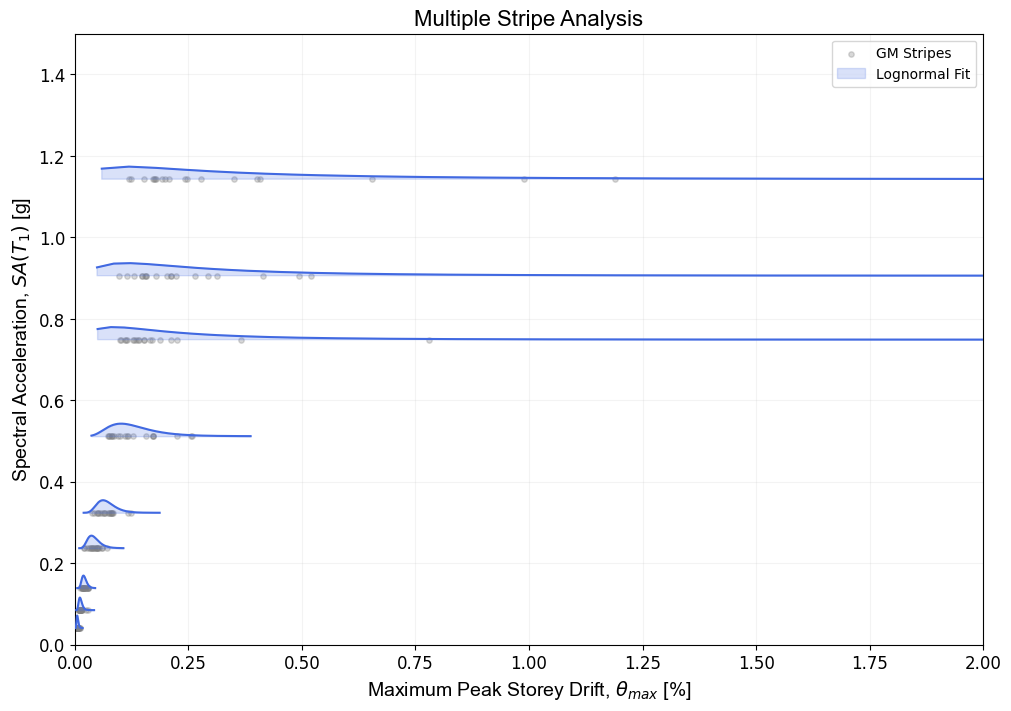

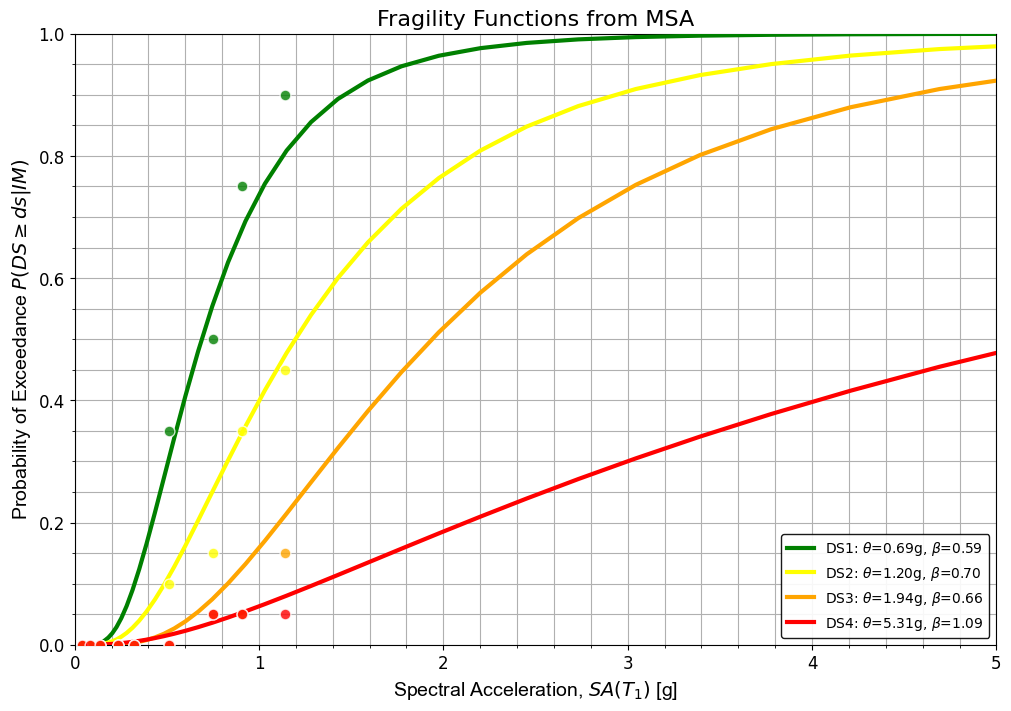

In [8]:
# Initialise the plotter class
pl=plotter()

# Plot the IDA curves
pl.plot_msa_analysis(imls_matrix,
                     edps_matrix,
                     imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                     edp_label   = r'Maximum Peak Storey Drift, $\theta_{max}$ [%]',
                     xlims       = [0, 2.0],
                     ylims       = [0, 1.5],
                     title       = 'Multiple Stripe Analysis',
                     pFlag       = True,
                     export_path = 'out/figures/msa_stripes.png')

pl.plot_fragility_from_msa(msa_dict,
                           imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                           title       = 'Fragility Functions from MSA',
                           xlims       = [0, 5],
                           ylims       = [0, 1],
                           pFlag       = True,
                           export_path = 'out/figures/fragility_curves.png')

## Post-Process Building-Level Vulnerability Functions based on Fragility Functions and Consequence Models ###

### Expected Loss Ratio (Mean Damage Ratio)

The vulnerability function expresses the expected loss ratio as a function of an intensity measure level (IM) and is obtained by convolving fragility functions with damage-to-loss ratios associated with each damage state.
Let $P(DS = ds_i \mid IM)$ denote the probability of the structure being in damage state $ds_i$ at a given intensity measure level $IM$, and let $\mu_{LR,i}$ be the mean loss ratio associated with that damage state. The expected loss ratio at intensity level $IM$, denoted as $E[LR \mid IM]$, is defined as

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

where:

* $N_{DS}$ is the total number of discrete damage states
* $P(DS = ds_i \mid IM)$ is derived from the fragility functions
* $\mu_{LR,i}$ is the mean loss ratio associated with damage state $ds_i$


#### Step 1: Calculate Damage-State Probabilities (i.e., Probabilities of Occurrence) from Fragility Functions

Fragility functions are commonly expressed in terms of probabilities of exceedance. The probability of being in a specific damage state is computed as

$$
P(DS = ds_i \mid IM) =
\begin{cases}
P(DS \ge ds_i \mid IM) - P(DS \ge ds_{i+1} \mid IM), & i < N_{DS} \
P(DS \ge ds_{N_{DS}} \mid IM), & i = N_{DS}
\end{cases}
$$

Assuming lognormal fragility functions, the probability of exceeding damage state $ds_i$ is given by

$$
P(DS \ge ds_i \mid IM) = 
\Phi\left(
\frac{\ln(IM) - \ln(\mu_{ds_i})}
{\beta_{ds_i}^{\text{total}}}
\right)
$$

where:

* $\mu_{ds_i}$ is the median intensity measure corresponding to damage state $ds_i$
* $\beta_{ds_i}^{\text{total}}$ is the total logarithmic standard deviation
* $\Phi(\cdot)$ is the standard normal cumulative distribution function

The total dispersion is computed as

$$
\beta_{ds_i}^{\text{total}} = 
\sqrt{
\beta_{\text{record-to-record}}^2
+
\beta_{\text{building-to-building}}^2
+
\beta_{\text{DS}}^2
}
$$

where:

* $\beta_{\text{record-to-record}}$ (or $\beta_{\text{EDP}\mid IM}$) represents ground-motion variability
* $\beta_{\text{building-to-building}}$ (or $\beta_{\text{MDL}}$) captures model and structural variability
* $\beta_{\text{DS}}$ represents uncertainty in damage-state definition and thresholds


#### Step 2: Calculation of Uncertainty in Expected Loss

#### Method 1: Silva [5] (Semi-Empirical)

When uncertainty in the damage-to-loss relationship is not explicitly modelled, the dispersion of the loss ratio conditional on the intensity measure can be estimated using the empirical formulation proposed by Silva [5].
The coefficient of variation of the loss ratio conditional on $IM$ is defined as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{\sigma_{LR \mid IM}}{E[LR \mid IM]}
$$

Following Silva [5], the standard deviation of the loss ratio is expressed as a function of the mean loss ratio:

$$
\sigma_{LR \mid IM} = 
0.5
\sqrt{
\overline{LR}_{\mid IM}
\left(
-0.7
* 2,\overline{LR}_{\mid IM}
- \sqrt{6.8,\overline{LR}_{\mid IM} + 0.5}
  \right)
  }
$$

where $\overline{LR}_{\mid IM}$ denotes the mean loss ratio conditional on the intensity measure level. This approach provides a conservative envelope for loss uncertainty and is commonly adopted when detailed loss information is unavailable.


#### Method 2: Explicit Statistical Propagation

Alternatively, the uncertainty in the expected loss ratio can be quantified by explicitly propagating uncertainty through the convolution of damage-state probabilities and damage-to-loss ratios. In this formulation, fragility functions account for uncertainty in structural response and damage-state thresholds, while additional uncertainty arises from variability in the damage-to-loss ratios associated with each damage state. The expected loss ratio conditional on $IM$ is given by

$$
E[LR \mid IM] = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM),\mu_{LR,i}
$$

Assuming the loss ratio conditional on each damage state is an independent random variable with coefficient of variation $\mathrm{COV}_{LR,i}$, the variance of the loss ratio conditional on $IM$ is computed using the **law of total variance**:

$$
\mathrm{Var}(LR \mid IM) = 
\sum_{i=1}^{N_{DS}}
P(DS = ds_i \mid IM)
\left[
\sigma_{LR,i}^2
+
\left(
\mu_{LR,i} - E[LR \mid IM]
\right)^2
\right]
$$

where

$$
\sigma_{LR,i} =
\mathrm{COV}*{LR,i},\mu*{LR,i}
$$

The coefficient of variation of the loss ratio conditional on the intensity measure is then computed as

$$
\mathrm{COV}(LR \mid IM) = 
\frac{
\sqrt{\mathrm{Var}(LR \mid IM)}
}{
E[LR \mid IM]
}
$$

This formulation captures both:

* uncertainty **within damage states** due to variability in damage-to-loss ratios, and
* uncertainty due to **damage-state mixing** as intensity varies.


### Note on Beta-Distribution Interpretation of the Vulnerability Function

The loss ratio conditional on intensity measure level $IM$ is assumed to follow a **Beta distribution** as one option in the OpenQuake Engine <dist='BT'> (https://docs.openquake.org/oq-engine/3.23/manual/user-guide/inputs/vulnerability-models-inputs.html), owing to its bounded support on the interval $[0,1]$ and its flexibility in representing skewed distributions.

$$
LR \mid IM \sim \mathrm{Beta}(\alpha(IM), \beta(IM))
$$

The Beta distribution parameters are obtained by matching the first two moments:

$$
\mu(IM) = E[LR \mid IM]
$$

$$
\sigma^2(IM) = \mathrm{Var}(LR \mid IM)
$$

Defining the precision parameter

$$
\kappa(IM) = \alpha(IM) + \beta(IM)
$$

the Beta parameters are computed as

$$
\kappa(IM) =
\frac{\mu(IM),[1-\mu(IM)]}{\sigma^2(IM)} - 1
$$

$$
\alpha(IM) = \mu(IM),\kappa(IM),
\qquad
\beta(IM) = [1-\mu(IM)],\kappa(IM)
$$

This assumption enables a complete probabilistic characterization of loss conditional on intensity measure level and is particularly suitable for risk calculations, loss aggregation, and Monte Carlo simulation within performance-based engineering frameworks.

In [9]:
# Define consequence model to relate structural damage to a decision variable (i.e., expected loss ratio) 
consequence_model = [0.05, 0.20, 0.60, 1.00] # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00] 

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_explicit_cov = pp.calculate_vulnerability_function(msa_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                            consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                            cov_consequence = consequence_cov,      # The coefficient of variation model representing the uncertainty around the loss ratios per damage state
                                                                            uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                            method='explicit')                      # Set method to explicit for COV calculation per law of total variance         

# Calculate the structural vulnerability function (using the explicit method)
structural_vulnerability_silva_cov = pp.calculate_vulnerability_function(msa_dict['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                         consequence_model,                      # The consequence model representing the normalised loss ratios per damage state
                                                                         uncertainty=True,                       # Set uncertainty equal to True to calculate COV of the Beta Distribution
                                                                         method='silva')                         # Set method to Silva for semi-empirical COV calculation     

## Plot the Vulnerability Functions with Uncertainty Visualisation ##

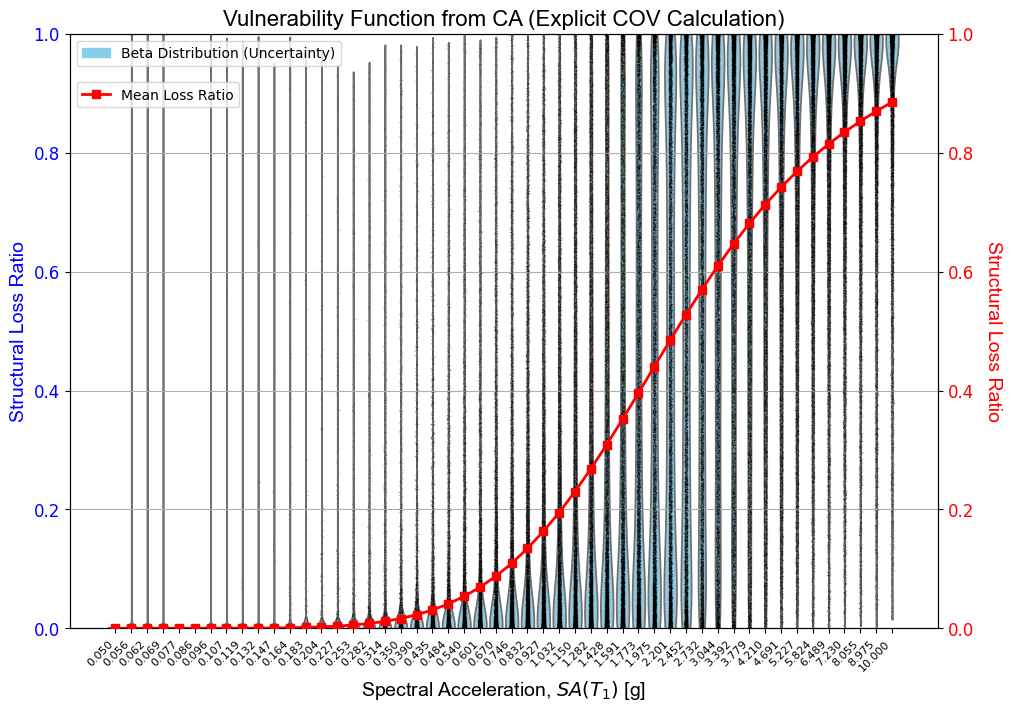

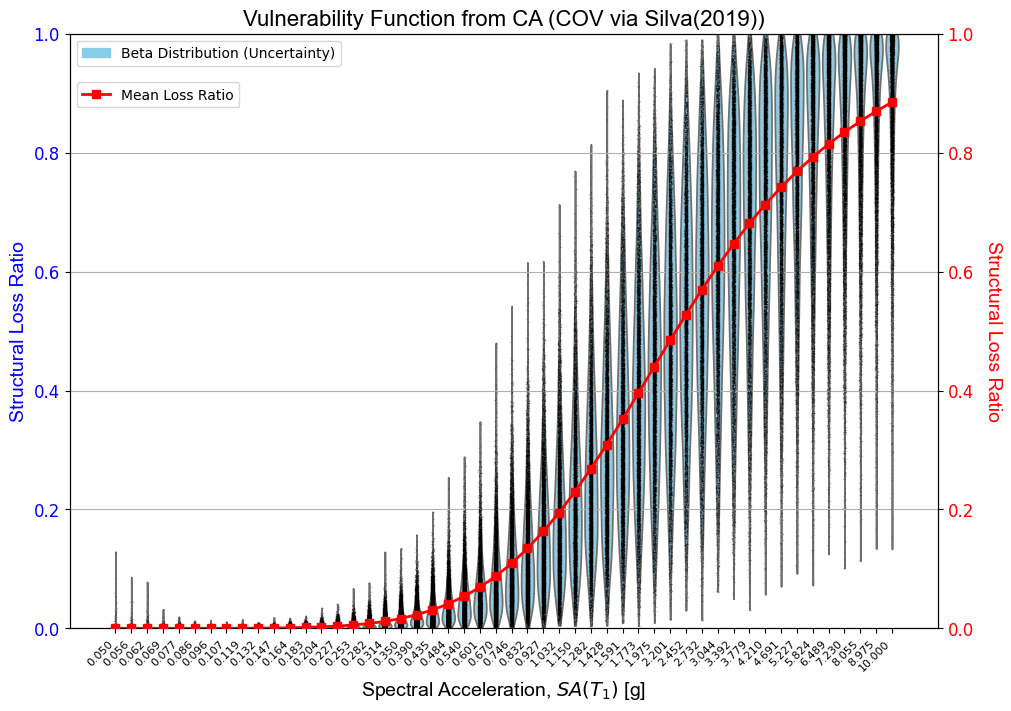

In [10]:
# Plot the structural vulnerability function from the explicit COV method
pl.plot_vulnerability_function(structural_vulnerability_explicit_cov['IML'],
                               structural_vulnerability_explicit_cov['Loss'],
                               structural_vulnerability_explicit_cov['COV'],
                               imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               loss_label  = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (Explicit COV Calculation)',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_explicit_cov.png')

# Plot the structural vulnerability function from the 'Silva (2019)' method
pl.plot_vulnerability_function(structural_vulnerability_silva_cov['IML'],
                               structural_vulnerability_silva_cov['Loss'],
                               structural_vulnerability_silva_cov['COV'],
                               imt_label   = r'Spectral Acceleration, $SA(T_{1})$ [g]',
                               loss_label  = 'Structural Loss Ratio',
                               title       = 'Vulnerability Function from CA (COV via Silva(2019))',
                               pFlag       = True,
                               export_path = 'out/figures/vulnerability_curve_silva_cov.png')